# Draft 2: XGBoost (re-implementation demo)

This notebook is a simple, reproducible example of training an **XGBoost classifier** using the scikit-learn style API (based on the official XGBoost docs).

- Reference implementation style: `https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html`


### What tools are available?
- **Libraries**: `xgboost` (XGBClassifier), `scikit-learn` (splits + metrics), `matplotlib`/`seaborn` (plots), optionally `shap` (interpretability).
- **Interpretability**: XGBoost feature importances; SHAP (TreeExplainer) for global + local explanations.

### What data sets are available?
- **Dataset**: labeled WhatsApp voice notes (Mom/Bestfriend/Professional), ideally shingled into short windows and augmented.
- **Public audio datasets (examples)**: ESC-50, UrbanSound8K (environmental sounds); Common Voice / LibriSpeech (speech).
- **Code-switching speech**: there are published code-switching corpora (e.g., SEAME), but licensing/format can be more involved.


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(94)

print("Python:", sys.executable)

try:
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (
        accuracy_score,
        f1_score,
        confusion_matrix,
        classification_report,
    )
except Exception as e:
    print("Could not import scikit-learn in this environment.")
    print("If you see a NumPy binary mismatch error, use a clean venv/conda env and reinstall numpy + scikit-learn.")
    raise

USE_XGBOOST = True
try:
    import xgboost as xgb
except Exception as e:
    USE_XGBOOST = False
    xgb = None
    print("Could not import xgboost in this environment.")
    print("Common macOS fix: install OpenMP runtime, then restart the kernel:")
    print("  brew install libomp")
    print("Then reinstall/upgrade xgboost (pip) or install via conda-forge.")
    print("\nFalling back to sklearn GradientBoostingClassifier so the demo still runs.")
    print("Original import error:\n", repr(e))


Python: /Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/bin/python
Could not import xgboost in this environment.
Common macOS fix: install OpenMP runtime, then restart the kernel:
  brew install libomp
Then reinstall/upgrade xgboost (pip) or install via conda-forge.

Falling back to sklearn GradientBoostingClassifier so the demo still runs.
Original import error:
 XGBoostError('\nXGBoost Library (libxgboost.dylib) could not be loaded.\nLikely causes:\n  * OpenMP runtime is not installed\n    - vcomp140.dll or libgomp-1.dll for Windows\n    - libomp.dylib for Mac OSX\n    - libgomp.so for Linux and other UNIX-like OSes\n    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.\n\n  * You are running 32-bit Python on a 64-bit OS\n\nError message(s): ["dlopen(/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D64

## Re-implement an available XGBoost version (small, real dataset)

To keep this demo self-contained and fast to run, I use a built-in dataset from scikit-learn.
In my Draft 2 pipeline, I will swap in my **audio feature matrix** (MFCC/RMS/silence + deltas) and my **3-class labels**.


In [ ]:
data = load_breast_cancer()
X = data["data"]
y = data["target"]
feature_names = data["feature_names"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=94, stratify=y
)

if USE_XGBOOST:
    clf = xgb.XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=94,
        eval_metric="logloss",
    )
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
else:
    # Fallback: still "boosted trees" (sklearn), so the demo runs everywhere.
    from sklearn.ensemble import GradientBoostingClassifier

    clf = GradientBoostingClassifier(random_state=94)
    clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Model: {'XGBoost' if USE_XGBOOST else 'sklearn GradientBoosting (fallback)'}")
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1:  {f1:.3f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))


Model: sklearn GradientBoosting (fallback)
Accuracy: 0.956
Macro F1:  0.952

Classification report:

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Confusion matrix

In my project, this will show whether the model confuses **Professional** with **Bestfriend**, etc.


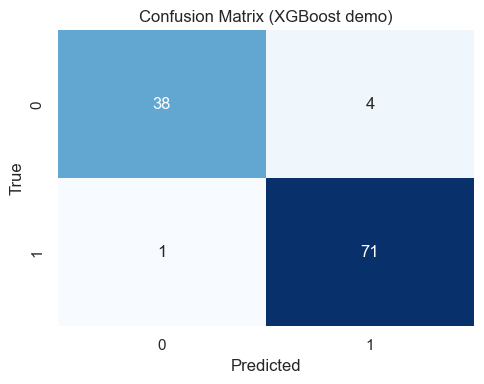

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
ax.set_title("Confusion Matrix (XGBoost demo)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()


## Feature importance

In my Draft 2, this is the quick interpretability win: I can map top features back to specific MFCC bands / energy / silence.


/var/folders/b6/4c8_xknx5r5gxvmks19_846w0000gn/T/ipykernel_70853/1718600055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[idx], y=np.array(feature_names)[idx], palette="viridis")


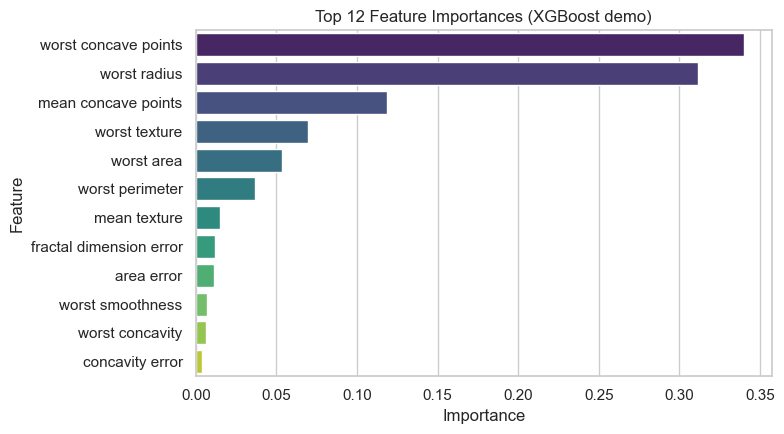

In [6]:
importances = clf.feature_importances_
top_k = 12
idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(8, 4.5))
sns.barplot(x=importances[idx], y=np.array(feature_names)[idx], palette="viridis")
plt.title(f"Top {top_k} Feature Importances (XGBoost demo)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
